## Data Understanding

In [48]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="5zCVxWKyvAR6oL372iVO")
project = rf.workspace("dami-gacor").project("dami-gacor")
version = project.version(2)
dataset = version.download("tensorflow")


loading Roboflow workspace...
loading Roboflow project...


Import Libraries dan Persiapan Data

In [49]:
import pandas as pd
import os

# Path ke dataset
dataset_path = '/content/Dami-Gacor-2'

# Mengatur jalur data pelatihan
train_path = os.path.join(dataset_path, 'train')
valid_path = os.path.join(dataset_path, 'valid')
test_path = os.path.join(dataset_path, 'test')

# Membaca file CSV
csv_path = os.path.join(dataset_path, 'train', '_annotations.csv')
df = pd.read_csv(csv_path)

# Memeriksa beberapa baris pertama dari CSV untuk memastikan strukturnya
print(df.head())  # Cek 5 baris pertama dari CSV untuk memastikan datanya benar


                                            filename  width  height  \
0  kubis-3_png.rf.fdae05a9b04f1a83cbdace1687b66f6...    640     640   
1  kubis-3_png.rf.fdae05a9b04f1a83cbdace1687b66f6...    640     640   
2  kubis-3_png.rf.fdae05a9b04f1a83cbdace1687b66f6...    640     640   
3  kubis-3_png.rf.fdae05a9b04f1a83cbdace1687b66f6...    640     640   
4  kubis-3_png.rf.fdae05a9b04f1a83cbdace1687b66f6...    640     640   

         class  xmin  ymin  xmax  ymax  
0  Tidak Sehat   231    61   251    85  
1  Tidak Sehat   211    68   232    96  
2  Tidak Sehat   185    70   206   101  
3  Tidak Sehat   164    75   181   107  
4  Tidak Sehat   138    81   163   113  


In [50]:
# Menelaah distribusi kelas
print(f"Jumlah kategori 'Sehat': {df[df['class'] == 'Sehat'].shape[0]}")
print(f"Jumlah kategori 'Tidak Sehat': {df[df['class'] == 'Tidak Sehat'].shape[0]}")

# Cek nilai unik di kolom 'filename'
print(f"Jumlah gambar unik: {df['filename'].nunique()}")


Jumlah kategori 'Sehat': 653
Jumlah kategori 'Tidak Sehat': 374
Jumlah gambar unik: 10


In [51]:
# Memeriksa apakah ada data yang hilang
print(f"Jumlah data hilang: \n{df.isnull().sum()}")

# Memeriksa apakah ada duplikasi gambar
print(f"Jumlah gambar duplikat: {df['filename'].duplicated().sum()}")


Jumlah data hilang: 
filename    0
width       0
height      0
class       0
xmin        0
ymin        0
xmax        0
ymax        0
dtype: int64
Jumlah gambar duplikat: 1017


In [52]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi 60% training, 20% validation, dan 20% testing
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# Menyimpan subset data dalam bentuk CSV untuk referensi
train_df.to_csv(os.path.join(dataset_path, 'train_data.csv'), index=False)
valid_df.to_csv(os.path.join(dataset_path, 'valid_data.csv'), index=False)
test_df.to_csv(os.path.join(dataset_path, 'test_data.csv'), index=False)

print(f"Jumlah data latih: {train_df.shape[0]}")
print(f"Jumlah data validasi: {valid_df.shape[0]}")
print(f"Jumlah data uji: {test_df.shape[0]}")


Jumlah data latih: 616
Jumlah data validasi: 205
Jumlah data uji: 206


In [53]:
# Menghapus duplikasi berdasarkan nama file
train_df = train_df.drop_duplicates(subset='filename')

# Memastikan tidak ada data yang hilang
print(f"Jumlah data hilang setelah penghapusan duplikat: \n{train_df.isnull().sum()}")


Jumlah data hilang setelah penghapusan duplikat: 
filename    0
width       0
height      0
class       0
xmin        0
ymin        0
xmax        0
ymax        0
dtype: int64


Pemetaan label ke format numerik

In [54]:
# Pemetaan label ke format numerik
label_mapping = {'Sehat': 0, 'Tidak Sehat': 1}

# Menambahkan kolom label numerik ke DataFrame
train_df['label'] = train_df['class'].map(label_mapping)


In [55]:
import os

# Verifikasi apakah jalur dataset ada dan apa isinya
dataset_path = '/content/Dami-Gacor-2'
print(os.listdir(dataset_path))  # Menampilkan daftar file di dalam folder dataset

['valid_data.csv', 'test', 'test_data.csv', 'train', 'README.roboflow.txt', 'train_data.csv', 'README.dataset.txt', 'valid']


In [56]:
# Tampilkan nama file unik dari DataFrame train_df
print(train_df['filename'].unique())

['10_png.rf.3d2a4fc0bef0d01ed126011165e1a423.jpg'
 '7_png.rf.459e3b94ec3f27ea1f8064f58bebe544.jpg'
 'kubis-2_png.rf.1aad573b6e8df9a7de96b3e53e5f8980.jpg'
 '3_png.rf.ef9454fb018381b2f6f1044b6b571caf.jpg'
 '2_png.rf.4ca79391729e7d65e11b98540c9987e1.jpg'
 'kubis-4_png.rf.039b49c80f3316d77b147ad92d3d129c.jpg'
 'kubis-7_png.rf.a8c36cdaf894715a6939cf2bd4eb447b.jpg'
 'kubis-3_png.rf.fdae05a9b04f1a83cbdace1687b66f60.jpg'
 'kubis-9_PNG.rf.9a18e30f0467f960081f1367c9df94ff.jpg'
 'kubis-10_PNG.rf.3284332fe498ac39824ff6351a483058.jpg']


In [57]:
import pandas as pd

# Path ke dataset
dataset_path = '/content/Dami-Gacor-2'

# Membaca data dari CSV
train_df = pd.read_csv(os.path.join(dataset_path, 'train_data.csv'))
valid_df = pd.read_csv(os.path.join(dataset_path, 'valid_data.csv'))
test_df = pd.read_csv(os.path.join(dataset_path, 'test_data.csv'))

In [58]:
print(train_df.head())  # Menampilkan beberapa baris pertama dari DataFrame pelatihan
print(valid_df.head())  # Menampilkan beberapa baris pertama dari DataFrame validasi
print(test_df.head())   # Menampilkan beberapa baris pertama dari DataFrame pengujian

                                            filename  width  height  class  \
0     10_png.rf.3d2a4fc0bef0d01ed126011165e1a423.jpg    640     640  Sehat   
1     10_png.rf.3d2a4fc0bef0d01ed126011165e1a423.jpg    640     640  Sehat   
2      7_png.rf.459e3b94ec3f27ea1f8064f58bebe544.jpg    640     640  Sehat   
3  kubis-2_png.rf.1aad573b6e8df9a7de96b3e53e5f898...    640     640  Sehat   
4      3_png.rf.ef9454fb018381b2f6f1044b6b571caf.jpg    640     640  Sehat   

   xmin  ymin  xmax  ymax  
0   558   260   608   372  
1   345   396   374   464  
2    74   318   185   509  
3   113    26   167    87  
4   275   303   302   345  
                                            filename  width  height  \
0     10_png.rf.3d2a4fc0bef0d01ed126011165e1a423.jpg    640     640   
1      2_png.rf.4ca79391729e7d65e11b98540c9987e1.jpg    640     640   
2  kubis-7_png.rf.a8c36cdaf894715a6939cf2bd4eb447...    640     640   
3      2_png.rf.4ca79391729e7d65e11b98540c9987e1.jpg    640     640   
4     10

## Data Preparation

In [59]:
import pandas as pd
import os
from PIL import Image
import numpy as np

# Daftar folder tempat gambar berada
image_folders = ['train', 'test', 'valid']  # Folder yang akan diperiksa

# Fungsi untuk memuat gambar dan anotasi
def load_single_image_and_annotations(csv_path, image_name, dataset_path):
    df = pd.read_csv(csv_path)  # Membaca ulang CSV untuk mendapatkan anotasi

    # Menyaring data untuk gambar tertentu
    group = df[df['filename'] == image_name]

    # Menyusun path gambar
    img_path = os.path.join(dataset_path, image_name)
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize gambar untuk konsistensi
    img_array = np.array(img) / 255.0  # Normalisasi

    # Mengambil anotasi untuk gambar ini (bounding box)
    return img_array, group[['class', 'xmin', 'ymin', 'xmax', 'ymax']].values

    # Memilih gambar secara acak dari dataset
    image_name = random.choice(train_df['filename'].unique())  # Menggunakan random.choice() untuk memilih gambar acak
    img_array, annotations = load_single_image_and_annotations(csv_path, image_name)

    # Verifikasi gambar dan anotasi
    print(f"Gambar yang dipilih: {image_name}")
    print(f"Anotasi untuk gambar: {annotations[:2]}")  # Tampilkan 2 anotasi pertama


In [60]:
# Fungsi untuk menyiapkan data
def prepare_data(df, csv_path, label_mapping, dataset_path):
    images = []
    labels = []  # Untuk menyimpan semua label dalam satu gambar

    for _, row in df.iterrows():
        img_array, annotations = load_single_image_and_annotations(csv_path, row['filename'], dataset_path)

        # Menyimpan label untuk gambar tersebut
        image_labels = [label_mapping.get(annotation[0], "Unknown") for annotation in annotations]  # Untuk beberapa label
        images.append(img_array)
        labels.append(image_labels)

    return np.array(images), labels  # Labels berupa list per gambar


In [61]:
import pandas as pd
import os
from PIL import Image
import numpy as np

# Fungsi untuk memuat gambar dan anotasi
def load_single_image_and_annotations(csv_path, image_name, dataset_path):
    df = pd.read_csv(csv_path)  # Membaca ulang CSV untuk mendapatkan anotasi

    # Menyaring data untuk gambar tertentu
    group = df[df['filename'] == image_name]

    # Menyusun path gambar yang benar
    img_path = os.path.join(dataset_path, 'train', image_name)  # Specify 'train' folder correctly

    # Load the image and handle potential errors
    try:
        img = Image.open(img_path)
        img = img.resize((224, 224))  # Resize gambar untuk konsistensi
        img_array = np.array(img) / 255.0  # Normalisasi
    except FileNotFoundError:
        print(f"File not found: {img_path}")
        return None, None  # Handle missing image case

    # Mengambil anotasi untuk gambar ini (bounding box)
    return img_array, group[['class', 'xmin', 'ymin', 'xmax', 'ymax']].values

# Fungsi untuk menyiapkan data
def prepare_data(df, csv_path, label_mapping, dataset_path):
    images = []
    labels = []  # Untuk menyimpan semua label dalam satu gambar

    for _, row in df.iterrows():
        img_array, annotations = load_single_image_and_annotations(csv_path, row['filename'], dataset_path)

        if img_array is None:  # Skip if the image couldn't be loaded
            continue

        # Menyimpan label untuk gambar tersebut
        image_labels = [label_mapping.get(annotation[0], "Unknown") for annotation in annotations]  # Untuk beberapa label
        images.append(img_array)
        labels.append(image_labels)

    return np.array(images), labels  # Labels berupa list per gambar

# Mengintegrasikan data latih
dataset_path = '/content/Dami-Gacor-2'
csv_path = os.path.join(dataset_path, 'train_data.csv')  # Path ke file CSV

# Membaca file CSV ke dalam DataFrame
train_df = pd.read_csv(csv_path)  # Memastikan file CSV dapat dibaca

# Misalkan Anda sudah memiliki label_mapping yang didefinisikan sebelumnya
# Memanggil fungsi prepare_data
X_train, y_train = prepare_data(train_df, csv_path, label_mapping, dataset_path)

# Verifikasi data
print(f"Data latih: {X_train.shape}, Labels latih: {len(y_train)}")

Data latih: (616, 224, 224, 3), Labels latih: 616


In [62]:
from PIL import Image
import numpy as np
import os

# Path to your dataset
dataset_path = '/content/Dami-Gacor-2'

# Function to preprocess the image
def preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.resize((224, 224))  # Resize the image
    img_array = np.array(img) / 255.0  # Normalize the pixel values
    return img_array

# Get the list of images in the train directory
train_directory = os.path.join(dataset_path, 'train')
train_images = os.listdir(train_directory)  # List all image files

print("Daftar gambar yang tersedia dalam folder train:", train_images)

# Select an image from the train directory (you can change this)
image_name = train_images[0]  # Just for example, select the first image

# Create the full path to the image
full_image_path = os.path.join(train_directory, image_name)

# Check if the image path exists, then preprocess it
if os.path.exists(full_image_path):
    img_array = preprocess_image(full_image_path)
    print(f"Gambar setelah preprocessing: {img_array.shape}")
else:
    print(f"Error: Gambar tidak ditemukan di path: {full_image_path}")

Daftar gambar yang tersedia dalam folder train: ['kubis-7_png.rf.a8c36cdaf894715a6939cf2bd4eb447b.jpg', '2_png.rf.4ca79391729e7d65e11b98540c9987e1.jpg', 'kubis-4_png.rf.039b49c80f3316d77b147ad92d3d129c.jpg', 'kubis-3_png.rf.fdae05a9b04f1a83cbdace1687b66f60.jpg', '10_png.rf.3d2a4fc0bef0d01ed126011165e1a423.jpg', 'kubis-9_PNG.rf.9a18e30f0467f960081f1367c9df94ff.jpg', 'kubis-2_png.rf.1aad573b6e8df9a7de96b3e53e5f8980.jpg', 'kubis-10_PNG.rf.3284332fe498ac39824ff6351a483058.jpg', '3_png.rf.ef9454fb018381b2f6f1044b6b571caf.jpg', '7_png.rf.459e3b94ec3f27ea1f8064f58bebe544.jpg', '_annotations.csv']
Gambar setelah preprocessing: (224, 224, 3)


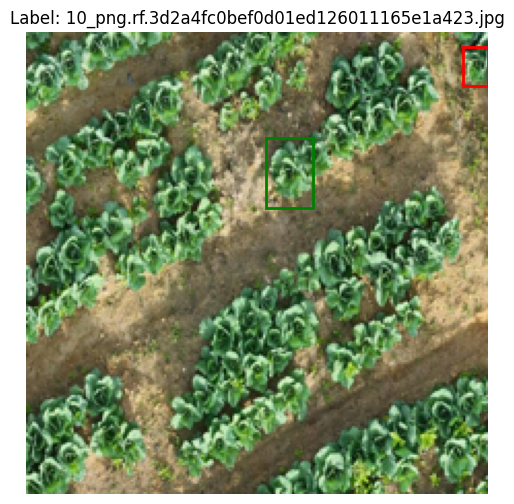

In [88]:
import matplotlib.pyplot as plt

# Fungsi untuk menampilkan gambar dengan bounding box
def display_image_with_boxes(image_array, annotations, image_name):
    plt.figure(figsize=(8, 6))
    plt.imshow(image_array)  # Menampilkan gambar

    # Menambahkan bounding box
    for row in annotations[:2]:  # Hanya mengambil 2 bounding box pertama
        label = row[0]  # Ambil label dari anotasi
        box = row[1:5]  # Ambil xmin, ymin, xmax, ymax dari anotasi
        color = 'green' if label == "Sehat" else 'red'  # Warna sesuai label

        # Menghitung koordinat bounding box sesuai ukuran gambar 224x224
        xmin_rescaled = box[0] * 224 / 640  # Corrected indexing
        ymin_rescaled = box[1] * 224 / 640  # Corrected indexing
        xmax_rescaled = box[2] * 224 / 640  # Corrected indexing
        ymax_rescaled = box[3] * 224 / 640  # Corrected indexing

        # Menambahkan bounding box ke gambar
        plt.gca().add_patch(plt.Rectangle((xmin_rescaled, ymin_rescaled),
                                            xmax_rescaled - xmin_rescaled,
                                            ymax_rescaled - ymin_rescaled,
                                            linewidth=2, edgecolor=color, facecolor='none'))

    plt.title(f"Label: {image_name}")
    plt.axis('off')  # Menyembunyikan axis
    plt.show()

# Misalkan img_array dan annotations sudah didefinisikan sebelumnya
# Membaca nama gambar dari anotasi dan menyiapkan input untuk fungsi
image_name = "10_png.rf.3d2a4fc0bef0d01ed126011165e1a423.jpg"  # Contoh nama gambar; ganti dengan yang sesuai

# Tampilkan gambar dengan bounding box
display_image_with_boxes(img_array, annotations, image_name)

In [64]:
import os
import pandas as pd
from PIL import Image
import numpy as np

# Daftar folder tempat gambar berada
image_folders = ['train', 'test', 'valid']  # Folder yang akan diperiksa

# Fungsi untuk memuat gambar dan anotasi
def load_single_image_and_annotations(csv_path, image_name, dataset_path):
    df = pd.read_csv(csv_path)  # Membaca ulang CSV untuk mendapatkan anotasi

    # Menyaring data untuk gambar tertentu
    group = df[df['filename'] == image_name]

    # Mencari gambar di folder yang tersedia
    img_path = None
    for folder in image_folders:
        potential_path = os.path.join(dataset_path, folder, image_name)
        if os.path.exists(potential_path):
            img_path = potential_path
            break  # Jika gambar ditemukan di salah satu folder, keluar dari loop

    # Jika gambar ditemukan, muat gambar dan anotasi
    if img_path is None:
        raise FileNotFoundError(f"Gambar {image_name} tidak ditemukan di folder manapun. Path yang dicoba: {img_path}")

    # Membuka gambar
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize gambar untuk konsistensi
    img_array = np.array(img) / 255.0  # Normalisasi gambar

    # Mengambil anotasi untuk gambar ini (bounding box)
    return img_array, group[['class', 'xmin', 'ymin', 'xmax', 'ymax']].values


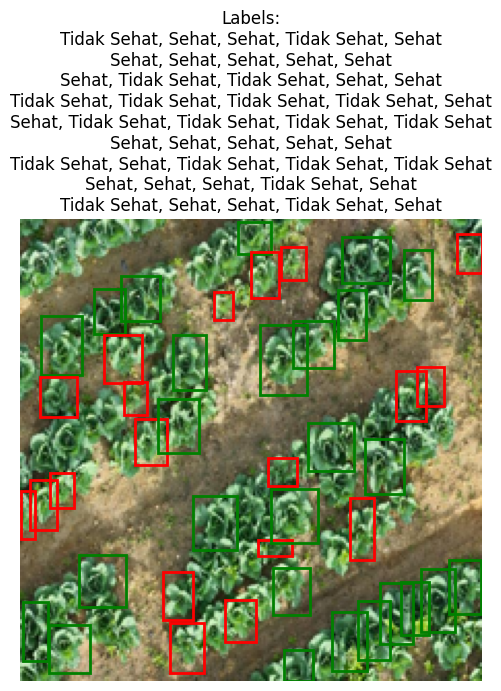

In [65]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import pandas as pd
import os

# Path ke dataset
dataset_path = '/content/Dami-Gacor-2'  # Sesuaikan dengan path utama dataset
csv_path = os.path.join(dataset_path, 'train_data.csv')  # Mengatur path ke file CSV
train_df = pd.read_csv(csv_path)

# Daftar folder tempat gambar berada
image_folders = ['train', 'test', 'valid']  # Folder yang akan diperiksa

# Fungsi untuk memuat gambar dan anotasi
def load_single_image_and_annotations(csv_path, image_name, dataset_path):
    df = pd.read_csv(csv_path)  # Membaca ulang CSV untuk mendapatkan anotasi

    # Menyaring data untuk gambar tertentu
    group = df[df['filename'] == image_name]

    # Mencari gambar di folder yang tersedia
    img_path = None
    for folder in image_folders:
        potential_path = os.path.join(dataset_path, folder, image_name)
        if os.path.exists(potential_path):
            img_path = potential_path
            break  # Jika gambar ditemukan di salah satu folder, keluar dari loop

    # Jika gambar ditemukan, muat gambar dan anotasi
    if img_path is None:
        raise FileNotFoundError(f"Gambar {image_name} tidak ditemukan di folder manapun.")

    # Membuka gambar
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize gambar untuk konsistensi
    img_array = np.array(img) / 255.0  # Normalisasi gambar

    # Mengambil anotasi untuk gambar ini (bounding box)
    return img_array, group[['class', 'xmin', 'ymin', 'xmax', 'ymax']].values

# Fungsi untuk menampilkan gambar dengan bounding box
def display_image_with_boxes(image_array, annotations):
    plt.figure(figsize=(8, 6))
    plt.imshow(image_array)  # Menampilkan gambar

    label_text = []  # List untuk menyimpan label yang akan ditampilkan

    # Menambahkan bounding box
    for row in annotations:  # Looping untuk semua bounding box
        label = row[0]
        box = row[1:5]  # xmin, ymin, xmax, ymax
        # Tentukan warna berdasarkan label
        color = 'green' if label == "Sehat" else 'red'  # Warna bounding box sesuai label

        # Menghitung koordinat bounding box sesuai ukuran gambar 224x224
        xmin_rescaled, ymin_rescaled = box[0] * 224 / 640, box[1] * 224 / 640
        xmax_rescaled, ymax_rescaled = box[2] * 224 / 640, box[3] * 224 / 640

        # Menambahkan bounding box ke gambar
        plt.gca().add_patch(plt.Rectangle((xmin_rescaled, ymin_rescaled),
                                          xmax_rescaled - xmin_rescaled,
                                          ymax_rescaled - ymin_rescaled,
                                          linewidth=2, edgecolor=color, facecolor='none'))

        # Menambahkan label ke dalam list untuk ditampilkan
        label_text.append(f"{label}")  # Menambahkan label dalam bentuk string

    # Menentukan jumlah maksimal label per baris
    labels_per_row = 5  # Misalnya, tampilkan 5 label per baris

    # Membagi label menjadi baris-baris dengan jumlah yang sama
    label_text_wrapped = "\n".join([', '.join(label_text[i:i + labels_per_row]) for i in range(0, len(label_text), labels_per_row)])

    # Membuat label agar rata kiri-kanan
    plt.title(f"Labels:\n{label_text_wrapped}")  # Gabungkan semua label dan tampilkan dalam beberapa baris
    plt.axis('off')  # Menyembunyikan axis
    plt.show()

# Memilih gambar secara acak dari dataset
image_name = random.choice(train_df['filename'].unique())
img_array, annotations = load_single_image_and_annotations(csv_path, image_name, dataset_path)

# Menampilkan gambar dengan bounding box
display_image_with_boxes(img_array, annotations)


Membuat Mask Berdasarkan Bounding Box

In [66]:
import numpy as np
from PIL import Image

# Fungsi untuk membuat mask berdasarkan bounding box
def create_mask(image_size, annotations, label_mapping):
    mask = np.zeros(image_size, dtype=np.uint8)  # Inisialisasi mask dengan 0
    for annotation in annotations:
        label = annotation[0]
        xmin, ymin, xmax, ymax = annotation[1:5]
        # Tentukan label numerik (misalnya "Sehat" = 0, "Tidak Sehat" = 1)
        mask_label = label_mapping.get(label, 1)  # Pemetaan label ke 0 atau 1

        # Mengisi area bounding box dengan nilai label
        mask[ymin:ymax, xmin:xmax] = mask_label
    return mask


Mempersiapkan Data (Gambar dan Mask)

In [67]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Inisialisasi ImageDataGenerator untuk augmentasi
datagen = ImageDataGenerator(
    rotation_range=30,      # Rotasi gambar
    width_shift_range=0.2,  # Geser gambar secara horizontal
    height_shift_range=0.2, # Geser gambar secara vertikal
    shear_range=0.2,        # Pemotongan gambar
    zoom_range=0.2,         # Zoom in/out gambar
    horizontal_flip=True,   # Membalik gambar secara horizontal
    fill_mode='nearest'     # Mengisi area yang kosong akibat transformasi
)


In [68]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from PIL import Image

# Pemetaan label numerik ke string
label_mapping = {'Sehat': 0, 'Tidak Sehat': 1}

# Membagi data menjadi 60% training, 20% validation, dan 20% testing
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# Menyimpan subset data dalam bentuk CSV untuk referensi
train_df.to_csv(os.path.join(dataset_path, 'train_data.csv'), index=False)
valid_df.to_csv(os.path.join(dataset_path, 'valid_data.csv'), index=False)
test_df.to_csv(os.path.join(dataset_path, 'test_data.csv'), index=False)

# Daftar folder tempat gambar berada
image_folders = ['train', 'test', 'valid']  # Folder yang akan diperiksa

# Fungsi untuk memuat gambar dan anotasi
def load_single_image_and_annotations(csv_path, image_name, dataset_path):
    df = pd.read_csv(csv_path)  # Membaca ulang CSV untuk mendapatkan anotasi

    # Menyaring data untuk gambar tertentu
    group = df[df['filename'] == image_name]

    # Mencari gambar di folder yang tersedia
    img_path = None
    for folder in image_folders:
        potential_path = os.path.join(dataset_path, folder, image_name)
        if os.path.exists(potential_path):
            img_path = potential_path
            break  # Jika gambar ditemukan di salah satu folder, keluar dari loop

    # Jika gambar ditemukan, muat gambar dan anotasi
    if img_path is None:
        raise FileNotFoundError(f"Gambar {image_name} tidak ditemukan di folder manapun.")

    # Membuka gambar
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize gambar untuk konsistensi
    img_array = np.array(img) / 255.0  # Normalisasi gambar

    # Mengambil anotasi untuk gambar ini (bounding box)
    return img_array, group[['class', 'xmin', 'ymin', 'xmax', 'ymax']].values

# Fungsi untuk membuat mask berdasarkan bounding box
def create_mask(image_size, annotations, label_mapping):
    mask = np.zeros(image_size[:2], dtype=np.uint8)  # Inisialisasi mask dengan ukuran height x width
    for annotation in annotations:
        label = annotation[0]
        xmin, ymin, xmax, ymax = annotation[1:5]
        mask_label = label_mapping.get(label, 1)  # Pemetaan label ke 0 (sehat) atau 1 (tidak sehat)
        mask[ymin:ymax, xmin:xmax] = mask_label  # Mengisi dengan 0 atau 1
    return mask

# Membuat fungsi untuk mempersiapkan data
def prepare_data(df, csv_path, label_mapping, dataset_path):
    images = []
    masks = []  # Menyimpan semua mask dalam satu gambar
    for _, row in df.iterrows():
        img_array, annotations = load_single_image_and_annotations(csv_path, row['filename'], dataset_path)
        image_mask = create_mask(img_array.shape, annotations, label_mapping)  # Membuat mask
        images.append(img_array)
        masks.append(image_mask)

    return np.array(images), np.array(masks)  # Mengembalikan gambar dan mask

# Mengintegrasikan data latih
X_train, y_train = prepare_data(train_df, csv_path, label_mapping, dataset_path)
X_valid, y_valid = prepare_data(valid_df, csv_path, label_mapping, dataset_path)
X_test, y_test = prepare_data(test_df, csv_path, label_mapping, dataset_path)

# Mengubah format y_train dan y_valid menjadi binary 1 channel
y_train_binary = np.expand_dims(np.where(y_train > 0, 1, 0), axis=-1)  # Menggunakan 1 channel
y_valid_binary = np.expand_dims(np.where(y_valid > 0, 1, 0), axis=-1)  # Sama dengan logika yang digunakan

# Memeriksa dimensi data
print(f"Data latih: {X_train.shape}, Labels latih: {y_train_binary.shape}")
print(f"Data validasi: {X_valid.shape}, Labels validasi: {y_valid_binary.shape}")
print(f"Data uji: {X_test.shape}, Labels uji: {y_test.shape}")


Data latih: (616, 224, 224, 3), Labels latih: (616, 224, 224, 1)
Data validasi: (205, 224, 224, 3), Labels validasi: (205, 224, 224, 1)
Data uji: (206, 224, 224, 3), Labels uji: (206, 224, 224)


## Modelling

Membangun Model U-Net

In [69]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.mixed_precision import set_global_policy, Policy  # Mixed precision

# Set mixed precision policy
policy = Policy('mixed_float16')
set_global_policy(policy)

# Define U-Net model
def unet_model(input_size=(224, 224, 3)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)  # Binary output
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create the U-Net model
model = unet_model()

# Display the model summary
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cast_2 (Cast)             │ (None, 224, 224, 3)    │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_38 (Conv2D)        │ (None, 224, 224, 64)   │          1,792 │ cast_2[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_39 (Conv2D)        │ (None, 224, 224, 64)   │         36,928 │ conv2d_38[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_8           │ (None, 112, 112, 64)   │              0 │ conv2d_39[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_40 (Conv2D)        │ (None, 112, 112, 128)  │         73,856 │ max_pooling2d_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_41 (Conv2D)        │ (None, 112, 112, 128)  │        147,584 │ conv2d_40[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_9           │ (None, 56, 56, 128)    │              0 │ conv2d_41[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_42 (Conv2D)        │ (None, 56, 56, 256)    │        295,168 │ max_pooling2d_9[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_43 (Conv2D)        │ (None, 56, 56, 256)    │        590,080 │ conv2d_42[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_10          │ (None, 28, 28, 256)    │              0 │ conv2d_43[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_44 (Conv2D)        │ (None, 28, 28, 512)    │      1,180,160 │ max_pooling2d_10[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_45 (Conv2D)        │ (None, 28, 28, 512)    │      2,359,808 │ conv2d_44[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_11          │ (None, 14, 14, 512)    │              0 │ conv2d_45[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_46 (Conv2D)        │ (None, 14, 14, 1024)   │      4,719,616 │ max_pooling2d_11[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_47 (Conv2D)        │ (None, 14, 14, 1024)   │      9,438,208 │ conv2d_46[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_8        │ (None, 28, 28, 512)    │      2,097,664 │ conv2d_47[0][0]        │
│ (Conv2DTranspose)    

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

Kompilasi Model

In [70]:
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np  # Pastikan import numpy jika belum dilakukan

# Kompilasi model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',  # Sesuaikan dengan masalah Anda (binary atau categorical)
              metrics=['accuracy'])

# Konversi label ke bentuk biner
y_train_binary = np.where(y_train > 0, 1, 0)  # Untuk data pelatihan
y_valid_binary = np.where(y_valid > 0, 1, 0)  # Untuk data validasi


Pelatihan Model

In [71]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# EarlyStopping untuk menghentikan pelatihan jika tidak ada perbaikan
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ReduceLROnPlateau untuk menurunkan learning rate jika val_loss stagnan
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

# Training dengan kedua callbacks
history = model.fit(
    X_train, y_train_binary,
    validation_data=(X_valid, y_valid_binary),
    epochs=50,  # Atur epochs lebih banyak karena early stopping akan menghentikan pelatihan lebih awal jika perlu
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 788ms/step - accuracy: 0.9059 - loss: 0.7289 - val_accuracy: 0.9199 - val_loss: 0.3378 - learning_rate: 0.0010
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 398ms/step - accuracy: 0.9262 - loss: 0.3289 - val_accuracy: 0.9199 - val_loss: 0.3027 - learning_rate: 0.0010
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 400ms/step - accuracy: 0.9225 - loss: 0.2887 - val_accuracy: 0.9199 - val_loss: 0.2822 - learning_rate: 0.0010
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 431ms/step - accuracy: 0.9228 - loss: 0.2711 - val_accuracy: 0.9199 - val_loss: 0.2816 - learning_rate: 0.0010
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 410ms/step - accuracy: 0.9246 - loss: 0.2653 - val_accuracy: 0.9199 - val_loss: 0.2707 - learning_rate: 0.0010
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 410ms/step - accuracy: 0.9266 - loss: 0.2523 - val_accuracy: 0.9199 - val_loss: 0.2987 - learning_rate: 0.0010
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 415ms/step - accuracy: 0.9242 - loss: 0.2753 

In [72]:
import numpy as np

# Misalkan y_test adalah label asli
# Mengonversi y_test menjadi bentuk biner (sesuaikan dengan kebutuhan dataset Anda)
y_test_binary = np.where(y_test > 0, 1, 0)  # Jika label lebih besar dari 0, ubah menjadi 1, jika tidak, 0

# Setelah pelatihan, evaluasi model pada dataset uji (test)
test_loss, test_accuracy = model.evaluate(X_test, y_test_binary)

# Print hasil evaluasi pada data uji
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - accuracy: 0.9212 - loss: 0.2678
Test Loss: 0.2628704607486725
Test Accuracy: 0.9230486750602722


In [73]:
# Menyimpan model setelah pelatihan
model.save('my_model.keras')

In [79]:
model.save('my_model.h5')


In [74]:
# Evaluasi model
test_loss, test_accuracy = model.evaluate(X_valid, y_valid_binary)  # Ubah y_valid jika perlu
print(f'Test loss: {test_loss:.4f}, Test accuracy: {test_accuracy:.4f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.9151 - loss: 0.2829
Test loss: 0.2707, Test accuracy: 0.9199


In [75]:
def display_image_with_boxes(image_array, annotations, mask):
    ...
    for row in annotations:
        ...
        color = 'green' if mask[int(ymin)][int(xmin)] == 0 else 'red'  # Menggunakan mask untuk warna
        ...

In [76]:
y_test_binary = np.array([[1, 0, 1],
                          [0, 1, 0],
                          [1, 1, 0],
                          [0, 0, 1],
                          [1, 0, 0]])

y_pred_binary = np.array([[0.9, 0.2, 0.8],  # Probabilitas untuk label 1, 2, 3
                          [0.1, 0.8, 0.2],
                          [0.7, 0.6, 0.1],
                          [0.3, 0.1, 0.9],
                          [0.8, 0.4, 0.3]])

# Ubah probabilitas ke label biner
y_pred_binary = (y_pred_binary > 0.5).astype(int)  # Menggunakan threshold 0.5

print(f"y_test_binary:\n{y_test_binary}")
print(f"y_pred_binary:\n{y_pred_binary}")


y_test_binary:
[[1 0 1]
 [0 1 0]
 [1 1 0]
 [0 0 1]
 [1 0 0]]
y_pred_binary:
[[1 0 1]
 [0 1 0]
 [1 1 0]
 [0 0 1]
 [1 0 0]]


In [77]:
from sklearn.metrics import precision_score, recall_score

# Precision dan Recall untuk multi-label classification
precision = precision_score(y_test_binary, y_pred_binary, average='micro')
recall = recall_score(y_test_binary, y_pred_binary, average='micro')

# Print hasil
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


Precision: 1.0000
Recall: 1.0000


In [78]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_binary.flatten(), y_pred_binary.flatten())
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[8 0]
 [0 7]]


In [80]:
from google.colab import files

# Untuk model .keras
files.download('my_model.keras')

# Atau jika model disimpan dalam format .h5
files.download('my_model.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [82]:
import os

# Mengecek ukuran file model
model_file_path = 'my_model.h5'  # Ganti dengan path model Anda
model_size = os.path.getsize(model_file_path)

# Menampilkan ukuran file dalam MB
print(f"Model size: {model_size / (1024 * 1024):.2f} MB")


Model size: 355.30 MB


In [81]:
import os

# Mengecek ukuran file model
model_file_path = 'my_model.keras'  # Ganti dengan path model Anda
model_size = os.path.getsize(model_file_path)

# Menampilkan ukuran file dalam MB
print(f"Model size: {model_size / (1024 * 1024):.2f} MB")


Model size: 592.06 MB


In [83]:
import shutil
shutil.make_archive('my_model_compressed', 'zip', 'my_model.keras')

'/content/my_model_compressed.zip'

In [85]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [86]:
model.save('/content/drive/MyDrive/my_model.keras')


In [87]:
model.save('/content/drive/MyDrive/my_model.h5')
